# Uniform linear grating coupler

Grating couplers are optical components used to efficiently couple light between optical fibers (or free-space beams) and integrated photonic waveguides. They consist of a periodic structure—typically etched onto the surface of a photonic chip—that diffracts incoming light into the waveguide mode (or vice versa). Grating couplers are widely used in silicon photonics due to their ease of fabrication, compatibility with planar processes, and ability to support wafer-scale testing. 

The simplest form of the grating coupler is the uniform linear grating coupler. In this notebook, we demonstrate the design workflow of such a device based on the silicon on insulator (SOI) platform. Conventionally, the initial design starts in 2D for faster speed and lower cost. Once the grating coupler is optimized in 2D, we construct the 3D version and can then potentially perform additional optimization to enhance its coupling efficiency. 

<img src="img/grating_coupler_schematic.png" width="400" alt="Schematic of the grating coupler">

More advanced grating coupler designs, such as the [focusing apodized grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/FocusedApodGC/) and the [inverse designed grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd19ApodizedCoupler/), can be realized to achieve higher performance.

In [20]:
import matplotlib.pylab as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

## Initial Design in 2D

We start with the 2D design and aim to optimize its coupling efficiency as much as possible. This way, the design process is faster and costs fewer FlexCredits.

First define the wavelength range of interest.

In [21]:
lda0 = 0.729  # central wavelength
freq0 = td.C_0 / lda0  # central frequency
ldas = np.linspace(0.679, 0.779, 25)  # wavelength range
freqs = td.C_0 / ldas  # frequency range
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))  # width of the source frequency range

Grating couplers are relatively narrow band device. Within the working bandwidth, the refractive indices of silicon and oxide don't change noticeably. Therefore, for simplicity we will just model them as nondispersive mediums. 

In [22]:
# Material Parameters

n_si = 3.70
si = td.Medium(permittivity=n_si**2)

n_sio2 = 1.45
sio2 = td.Medium(permittivity=n_sio2**2)

n_si3n4 = 2.03
si3n4 = td.Medium(permittivity=n_si3n4**2)

n_tio2 = 2.54
tio2 = td.Medium(permittivity=n_tio2**2)

In [23]:
# Waveguide / Grating Parameters
height_wg = 0.260           # Thickness of Si3N4 waveguide (260 nm)
etch_depth = 0.180     # Etch depth (180 nm)
n_teeth = 20          # Number of grating periods
len_wg = 1.0
len_wg_end = 3.0


# Cladding Parameters
box_thickness = 1.0   # SiO2 thickness ABOVE and BELOW the grating

# Source Parameters
source_angle_deg = 10.0
theta = np.deg2rad(source_angle_deg)
mfd = 1.5           # Mode field diameter (fiber)
source_pos_x = 6.0      # FIXED Source Position (x=0)

# DBR Parameters (Calculated for lambda/4)
t_dbr_high = lda0 / (4 * n_tio2)  # TiO2 thickness (~72 nm)
t_dbr_low = lda0 / (4 * n_sio2)   # SiO2 thickness (~126 nm)
n_dbr_pairs = 10                  # Number of DBR pairs
si_thickness = lda0

To enable parameter sweeping in optimizing the design, we define a function that takes the design parameters as arguments and returns a [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) object. In the simulation, we use a [GaussianBeam](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.GaussianBeam.html) source to represent the incident field from the single-mode fiber. A [ModeMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeMonitor.html) is added on the waveguide to measure the coupling efficiency, which will be used as the figure of merit for our design optimization.

Since this simulation is 2D, the boundary condition is set to periodic in the $y$ direction.

In [24]:
# ==============================================================================
# 3. Simulation Builder Function
# ==============================================================================
def make_2d_sim(p: float, ff: float, box_thickness: float) -> td.Simulation:
    """
    Creates a 2D simulation for a given Grating Period (p) and Fill Factor (ff).
    """
    
    # --- A. Define Static Structures (Cladding & DBR) ---
    
    structures = []
    inf_eff = 100 # Large number for infinite extent
    
    # 1. Top Oxide (starts at waveguide top, goes up by box_thickness)
    structures.append(td.Structure(
        geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, height_wg), rmax=(inf_eff, inf_eff, inf_eff)),
        medium=sio2,
        name="Top Oxide"
    ))
    
    # 2. Bottom Oxide (starts at 0, goes down by box_thickness)
    structures.append(td.Structure(
        geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -box_thickness), rmax=(inf_eff, inf_eff, 0)),
        medium=sio2,
        name="Bottom Oxide"
    ))

    # 3. DBR Stack (Starts at bottom of Bottom Oxide: z = -box_thickness)
    current_z = -box_thickness
    
    for i in range(n_dbr_pairs):
        # High Index Layer (TiO2)
        structures.append(td.Structure(
            geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, current_z - t_dbr_high), rmax=(inf_eff, inf_eff, current_z)),
            medium=tio2,
            name=f"DBR_High_{i}"
        ))
        current_z -= t_dbr_high
        
        # Low Index Layer (SiO2)
        structures.append(td.Structure(
            geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, current_z - t_dbr_low), rmax=(inf_eff, inf_eff, current_z)),
            medium=sio2,
            name=f"DBR_Low_{i}"
        ))
        current_z -= t_dbr_low

    # 4. Silicon Substrate (Everything below DBR)
    structures.append(td.Structure(
        geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, current_z)),
        medium=si,
        name="Substrate"
    ))

    # --- B. Define Waveguide & Grating (Si3N4) ---
    
    waveguide = td.Structure(
        geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(inf_eff, inf_eff, height_wg)),
        medium=si3n4
    )


    structures.append(waveguide)

    grating_len = n_teeth * p
    start_x = -grating_len/2
    gratings = 0
    for i in range(n_teeth):
            gratings += td.Box.from_bounds(
                rmin=(p*(i + ff) + len_wg, -inf_eff, (height_wg-etch_depth)),
                rmax=(p*(i+1) + len_wg, inf_eff, height_wg)
            )
    gratings = td.Structure(geometry=gratings, medium=sio2)
    structures.append(gratings)
    # --- C. Source & Monitor ---
    
    # Source: Gaussian Beam from Top, aiming down
    source = td.GaussianBeam(
        size=(4 * mfd, td.inf, 0),
        center=[source_pos_x, 0, height_wg + box_thickness - 0.5], # Start inside top oxide
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        angle_theta=theta, # Angle relative to Z-axis (normal incidence = 0)
        direction="-", # Propagating DOWN (-z)
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2, # TE Polarization
        name="GaussianSource"
    )

    # Monitor: Mode monitor in the waveguide (Left side, aiming left)
    # We want to catch light coupling into the waveguide moving towards -x (or +x).
    # Since Gaussian is usually centered, light couples both ways. Let's monitor -x.
    mode_monitor = td.ModeMonitor(
        center=(0.2, 0, height_wg / 2), # 2um to the left of grating
        size=(0, td.inf, 2*height_wg), # Vertical slice
        freqs=[freq0],
        mode_spec=td.ModeSpec(num_modes=1, target_neff=2.01), # Guess neff for Si3N4 TE00
        name="mode_monitor",
    )

    # xz plane field monitor for visualization
    field_monitor = td.FieldMonitor(
        center=(0, 0, 0),
        size=(td.inf, 0, td.inf), # Infinite X and Z, 0 thickness in Y
        freqs=[freq0],
        name="field_xz"
    )
    # --- D. Simulation Setup ---
    
    height_dbr = n_dbr_pairs*((lda0/(4*n_sio2) + (lda0/(4*n_tio2))))
    sim_box_size = (grating_len + len_wg + len_wg_end, 0, si_thickness + height_dbr + height_wg + 2*box_thickness) 
    
    sim = td.Simulation(
        center=((len_wg + p*n_teeth + len_wg_end)/2, 0, -(box_thickness + height_dbr + si_thickness) + (1/2)*(height_dbr + height_wg + 2*box_thickness + si_thickness)),
        size=sim_box_size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=30, wavelength=lda0),
        structures=structures,
        sources=[source],
        monitors=[mode_monitor] + [field_monitor],
        run_time=2e-12,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.periodic(),
            z=td.Boundary.pml(),
        ),
    )
    
    return sim

Output()

16:03:13 PST Started working on Batch containing 5 tasks.

16:03:16 PST Maximum FlexCredit cost: 0.219 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

16:03:19 PST Batch complete.

/tmp/ipykernel_5503/3711866595.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coupling_efficiency[i, j] = np.abs(res)**2
/tmp/ipykernel_5503/3711866595.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coupling_efficiency[i, j] = np.abs(res)**2
/tmp/ipykernel_5503/3711866595.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coupling_efficiency[i, j] = np.abs(res)**2
/tmp/ipykernel_5503/3711866595.py:23: DeprecationWarning: Conversion of an array with nd

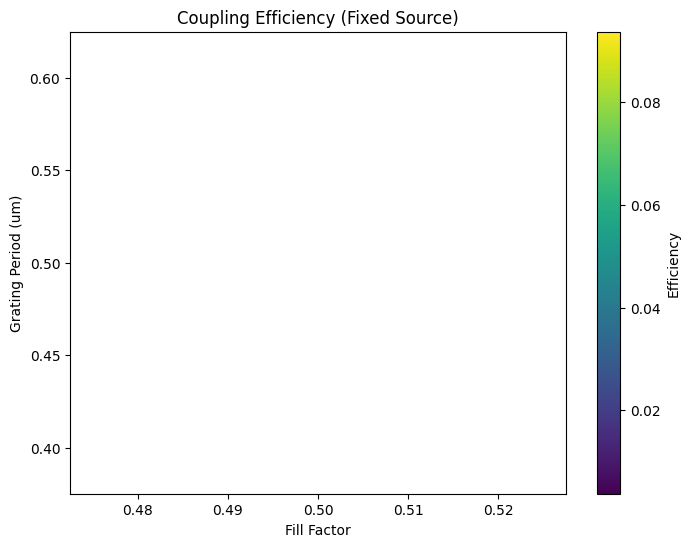

In [ ]:
# Sweep Parameters
period_list = np.linspace(0.40, 0.60, 5)   # Sweep Period (um) - adjusted for 729nm/Si3N4
ff_list = np.linspace(0.5, 0.5, 1)         # Sweep Fill Factor

# Create Simulation Batch
sims_to_run = {}
for p in period_list:
    for ff in ff_list:
        sim_name = f"P={p}_FF={ff}"
        sims_to_run[sim_name] = make_2d_sim(p, ff, box_thickness)

# --- RUNNING THE BATCH (Uncomment to actually run) ---
batch = web.Batch(simulations=sims_to_run)
batch_results = batch.run(path_dir="data")

# --- PLOTTING RESULTS (Mockup Logic) ---
coupling_efficiency = np.zeros((len(period_list), len(ff_list)))
for i, p in enumerate(period_list):
    for j, ff in enumerate(ff_list):
        sim_name = f"P={p}_FF={ff}"
        # Extract transmission to fundamental mode
        res = batch_results[sim_name]["mode_monitor"].amps.sel(direction="-").values
        coupling_efficiency[i, j] = np.abs(res)**2
plt.figure(figsize=(8, 6))
plt.pcolormesh(ff_list, period_list, coupling_efficiency, cmap='viridis', shading='auto')
plt.xlabel('Fill Factor')
plt.ylabel('Grating Period (um)')
plt.title('Coupling Efficiency (Fixed Source)')
plt.colorbar(label='Efficiency')
plt.show()

Visualizing geometry for P=0.5, FF=0.5...


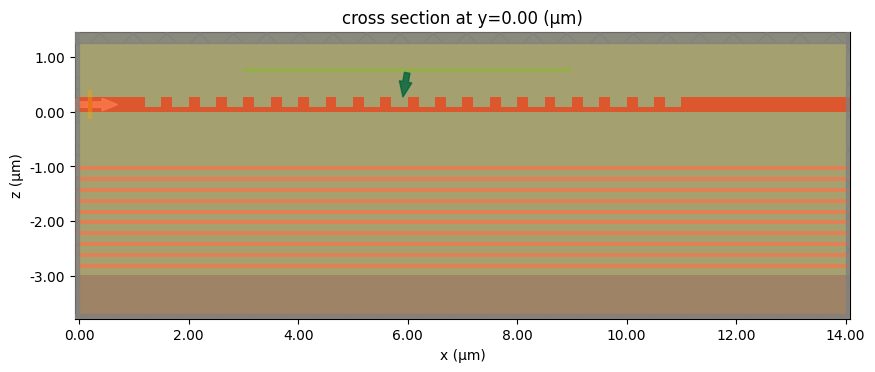

In [28]:
# Visualize one simulation to check geometry
print("Visualizing geometry for P=0.5, FF=0.5...")
sim_preview = make_2d_sim(p=0.5, ff=0.4, box_thickness=box_thickness)
fig, ax = plt.subplots(figsize=(10, 8))
sim_preview.plot(y=0, ax=ax)
plt.show()

16:11:07 PST Created task 'test_sim' with resource_id                           
             'fdve-916a4f41-a934-434c-a80a-c2a406d07c5c' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=576497;https://tidy3d.simulation.cloud/workbench?taskId=fdve-916a4f41-a934-434c-a80a-c2a406d07c5c\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=192417;https://tidy3d.simulation.cloud/workbench?taskId=fdve-916a4f41-a934-434c-a80a-c2a406d07c5c\taskId]8;;\]8;id=576497;https://tidy3d.simulation.cloud/workbench?taskId=fdve-916a4f41-a934-434c-a80a-c2a406d07c5c\=]8;;\]8;id=381214;https://tidy3d.simulation.cloud/workbench?taskId=fdve-916a4f41-a934-434c-a80a-c2a406d07c5c\fdve]8;;\]8;id=576497;https://tidy3d.simulation.cloud/workbench?taskId=fdve-916a4f41-a934-434c-a80a-c2a406d07c5c\-916a4f41-a93]8;;\
             ]8;id=576497;https://tidy3d.simulation.cloud/workbench?taskId=fdve-916a4f41-a934-434c-a80a-c2a406d07c5c\4-434c-a80a-c2a406d07c5c']8;;\.

             Task folder: ]8;id=722789;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

             Estimated FlexCredit cost: 0.044. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

16:11:08 PST status = success

Output()

16:11:10 PST Loading simulation from data/2d_gc_test.hdf5

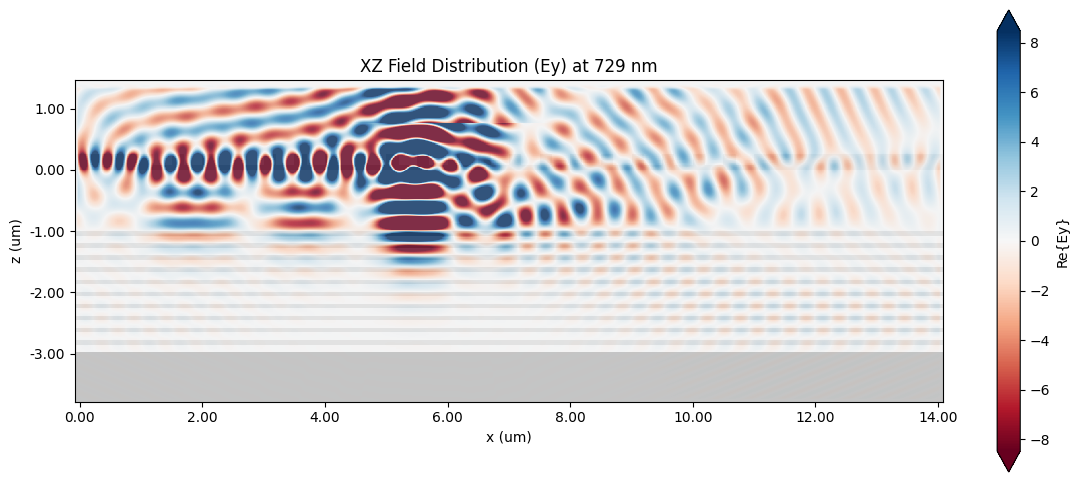

---------------------------------------------------
Coupling Efficiency: [0.11149379]
Insertion Loss:      [-9.52749308] dB
---------------------------------------------------


In [29]:
web.cache.clear()
sim_data = web.run(simulation=sim_preview, task_name="test_sim", path="data/2d_gc_test.hdf5")
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the Real part of Ey (Electric field in y-direction, which is dominant for TE)
# 'val="real"' shows the wave propagation (ripples). 'val="abs"' shows the intensity envelope.
sim_data.plot_field(
    field_monitor_name="field_xz", 
    field_name="Ey", 
    val="real", 
    ax=ax
)
#sim_preview.plot(y=0, ax=ax, alpha=0.2, edge_color="white")

ax.set_title(f"XZ Field Distribution (Ey) at {lda0*1000:.0f} nm")
ax.set_xlabel("x (um)")
ax.set_ylabel("z (um)")
plt.show()
mode_amp = sim_data["mode_monitor"].amps.sel(direction="-", f=freq0).values

# Efficiency is Amplitude squared
coupling_efficiency = np.abs(mode_amp)**2
db_efficiency = 10 * np.log10(coupling_efficiency)

print(f"---------------------------------------------------")
print(f"Coupling Efficiency: {coupling_efficiency}")
print(f"Insertion Loss:      {db_efficiency} dB")
print(f"---------------------------------------------------")

## Box Size Sweep

In [38]:
thickness_list = np.linspace(1.8, 2.0, 8)
# Generate Batch
sims_box = {}
for t in thickness_list:
    sim_name = f"BOX={t}"
    sims_box[sim_name] = make_2d_sim(p=0.5, ff=0.4, box_thickness=t)

# ==============================================================================
# 4. Run Batch & Extract Results
# ==============================================================================
batch = web.Batch(simulations=sims_box)
batch_results = batch.run(path_dir="data/box_sweep")

Output()

16:31:08 PST Started working on Batch containing 8 tasks.

16:31:12 PST Maximum FlexCredit cost: 0.425 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

16:32:15 PST Batch complete.

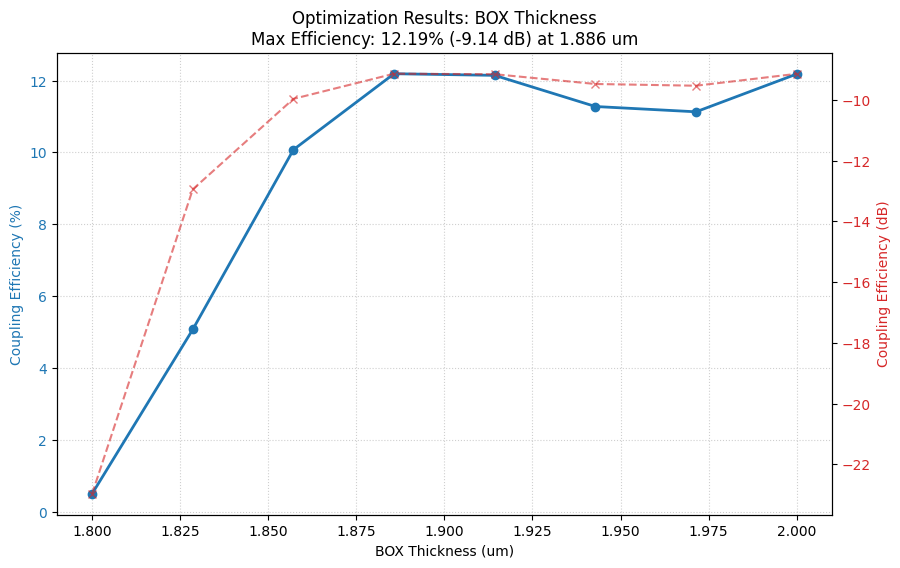

Optimal BOX Thickness: 1.886 um


In [40]:
extracted_efficiencies = []
extracted_db = []

for t in thickness_list:
    # Reconstruct the key name exactly as it was created
    sim_name = f"BOX={t}"
    
    # Retrieve the specific simulation data
    if sim_name not in batch_results:
        print(f"Warning: {sim_name} not found in results!")
        continue
        
    sim_data = batch_results[sim_name]
    
    mode_amp = sim_data["mode_monitor"].amps.sel(f=freq0, direction="-").values.item()
    eff = np.abs(mode_amp)**2
    extracted_efficiencies.append(eff)

    # Calculate dB (avoid log(0) error)
    if eff > 0:
        extracted_db.append(10 * np.log10(eff))
    else:
        extracted_db.append(-100) # Floor for zero power

# Convert to numpy array for easier plotting
extracted_efficiencies = np.array(extracted_efficiencies)
extracted_db = np.array(extracted_db)

# ==============================================================================
# 5. Plotting the Real Data
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Linear Efficiency (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('BOX Thickness (um)')
ax1.set_ylabel('Coupling Efficiency (%)', color=color)
ax1.plot(thickness_list, extracted_efficiencies * 100, 'o-', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Create a second axis for dB (Right Axis)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Coupling Efficiency (dB)', color=color)  
ax2.plot(thickness_list, extracted_db, 'x--', color=color, alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

# Find and Annotate the Maximum
max_idx = np.argmax(extracted_efficiencies)
max_eff = extracted_efficiencies[max_idx]
max_thick = thickness_list[max_idx]

plt.title(f"Optimization Results: BOX Thickness\nMax Efficiency: {max_eff:.2%} (-{np.abs(extracted_db[max_idx]):.2f} dB) at {max_thick:.3f} um")
plt.show()

print(f"Optimal BOX Thickness: {max_thick:.3f} um")